# fio DFS rand_write — Buffered (page cache) vs O_DIRECT — nj=16 / iod=16

Compares `direct=0` (buffered / page cache) results in `../fio-dfs-rand_write_pagecache/`
against the matching `nj=16, iod=16` slice of the O_DIRECT `256io` sweep in
`../fio-dfs-256io-sweep/` (bs=1M, numjobs=16, iodepth=16 for both — the only
difference is `direct`/`buffered`).


In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

PAGECACHE_DIR = Path(".")
DIRECT_DIR = Path("../fio-dfs-256io-sweep")


In [2]:
FNAME_RE = re.compile(
    r"fio_(?:dfs_direct(?P<direct>\d)_)?bs(?P<bs>\S+?)_nj(?P<nj>\d+)_iod(?P<iod>\d+)_(?P<ts>\d+)\.json$"
)

def parse_file(fpath, mode):
    m = FNAME_RE.search(Path(fpath).name)
    nj, iod, ts = int(m.group("nj")), int(m.group("iod")), int(m.group("ts"))

    with open(fpath) as f:
        d = json.load(f)

    job  = d["jobs"][0]
    w    = job["write"]
    slat = w["slat_ns"]
    clat = w["clat_ns"]
    lat  = w["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        mode            = mode,
        numjobs         = nj,
        iodepth         = iod,
        run_ts          = ts,
        bw_GiBs         = w["bw"] / 1024 / 1024,
        iops            = w["iops"],
        slat_mean_ms    = ms(slat["mean"]),
        clat_50th_ms    = ms(cp["50.000000"]),
        clat_90th_ms    = ms(cp["90.000000"]),
        clat_99th_ms    = ms(cp["99.000000"]),
        clat_99_9th_ms  = ms(cp["99.900000"]),
        clat_99_99th_ms = ms(cp["99.990000"]),
        lat_mean_ms     = ms(lat["mean"]),
        lat_max_ms      = ms(lat["max"]),
        usr_cpu         = job["usr_cpu"],
        sys_cpu         = job["sys_cpu"],
    )

# Buffered / page-cache runs — all already nj=16, iod=16
pagecache_files = sorted(PAGECACHE_DIR.glob("*.json"))

# Matching O_DIRECT slice from the 256io sweep: only the nj=16/iod=16 config
direct_files = sorted(DIRECT_DIR.glob("fio_bs1M_nj16_iod16_*.json"))

rows = (
    [parse_file(f, "buffered (direct=0)") for f in pagecache_files]
    + [parse_file(f, "O_DIRECT (direct=1)") for f in direct_files]
)
df_all = pd.DataFrame(rows).sort_values(["mode", "run_ts"]).reset_index(drop=True)

n_runs = df_all.groupby("mode").size()
print("Runs loaded per mode:")
print(n_runs)


Runs loaded per mode:
mode
O_DIRECT (direct=1)    11
buffered (direct=0)    10
dtype: int64


## Median / Mean / Std per mode

In [3]:
METRICS = [
    "bw_GiBs", "iops",
    "slat_mean_ms",
    "clat_50th_ms", "clat_90th_ms", "clat_99th_ms", "clat_99_9th_ms", "clat_99_99th_ms",
    "lat_mean_ms", "lat_max_ms",
    "usr_cpu", "sys_cpu",
]

def cv_pct(x):
    m = x.mean()
    return x.std() / m * 100 if m != 0 else 0.0

df_stats = df_all.groupby("mode")[METRICS].agg(["mean", "std", "median", cv_pct])
df_stats.columns = ["_".join(c) for c in df_stats.columns]

df_median = df_all.groupby("mode")[METRICS].median().reset_index()

print("Median values per mode:")
df_median.round(3)


Median values per mode:


,mode,bw_GiBs,iops,slat_mean_ms,clat_50th_ms,clat_90th_ms,clat_99th_ms,clat_99_9th_ms,clat_99_99th_ms,lat_mean_ms,lat_max_ms,usr_cpu,sys_cpu
0,O_DIRECT (direct=1),22.932,23481.998,0.037,9.372,16.450,26.345,42.205,71.827,10.818,158.355,93.714,3.668
1,buffered (direct=0),22.907,23457.089,0.044,10.027,13.107,21.103,42.992,72.876,10.905,104.950,93.677,3.553


## Run Variability (CV%)

In [4]:
cv_cols = [f"{m}_cv_pct" for m in METRICS]
cv_table = df_stats[cv_cols].copy()
cv_table.columns = METRICS

RENAME = {
    "bw_GiBs": "BW (GiB/s)", "iops": "IOPS", "slat_mean_ms": "slat mean",
    "clat_50th_ms": "clat P50", "clat_90th_ms": "clat P90",
    "clat_99th_ms": "clat P99", "clat_99_9th_ms": "clat P99.9",
    "clat_99_99th_ms": "clat P99.99",
    "lat_mean_ms": "lat mean", "lat_max_ms": "lat max",
    "usr_cpu": "usr CPU", "sys_cpu": "sys CPU",
}
cv_table = cv_table.rename(columns=RENAME)

def highlight_high_cv(val):
    if isinstance(val, (int, float)) and val > 5.0:
        return "background-color: #FF6B6B; color: white; font-weight: bold"
    return ""

display(
    cv_table.style
    .map(highlight_high_cv)
    .format("{:.2f}%")
    .set_caption("Run-to-Run Variability — CV% per mode (red = CV > 5%)")
)


,BW (GiB/s),IOPS,slat mean,clat P50,clat P90,clat P99,clat P99.9,clat P99.99,lat mean,lat max,usr CPU,sys CPU
mode,,,,,,,,,,,,
O_DIRECT (direct=1),0.89%,0.89%,1.53%,1.26%,0.96%,1.18%,2.10%,11.86%,0.92%,15.95%,0.09%,1.23%
buffered (direct=0),2.19%,2.19%,2.42%,2.43%,4.46%,3.30%,12.36%,18.74%,2.27%,36.12%,0.11%,1.55%


## Bandwidth & IOPS

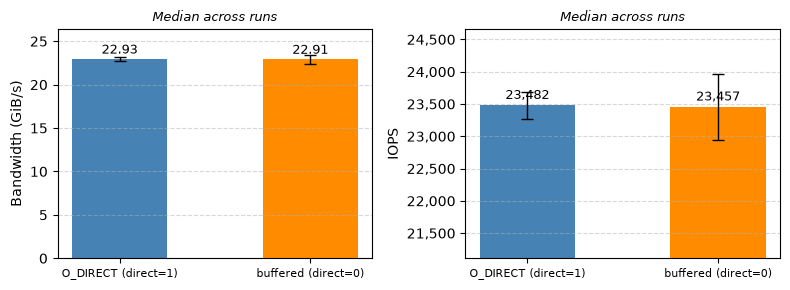

In [5]:
df = df_median

bw_std   = df_stats["bw_GiBs_std"].values
iops_std = df_stats["iops_std"].values

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar(df["mode"], df["bw_GiBs"], color=["steelblue", "darkorange"], width=0.5,
            yerr=bw_std, capsize=4, error_kw=dict(elinewidth=1, ecolor="black", capthick=1))
axes[0].set_ylabel("Bandwidth (GiB/s)")
axes[0].set_ylim(0, df["bw_GiBs"].max() * 1.15)
for bar, v in zip(axes[0].patches, df["bw_GiBs"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{v:,.2f}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Median across runs", fontsize=9, style="italic")

axes[1].bar(df["mode"], df["iops"], color=["steelblue", "darkorange"], width=0.5,
            yerr=iops_std, capsize=4, error_kw=dict(elinewidth=1, ecolor="black", capthick=1))
axes[1].set_ylabel("IOPS")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].set_ylim(df["iops"].min() * 0.9, df["iops"].max() * 1.05)
for bar, v in zip(axes[1].patches, df["iops"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Median across runs", fontsize=9, style="italic")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig("bw_iops_pagecache_vs_direct.pdf", dpi=150)
plt.show()


## Latency Comparison (percentiles + mean/max)

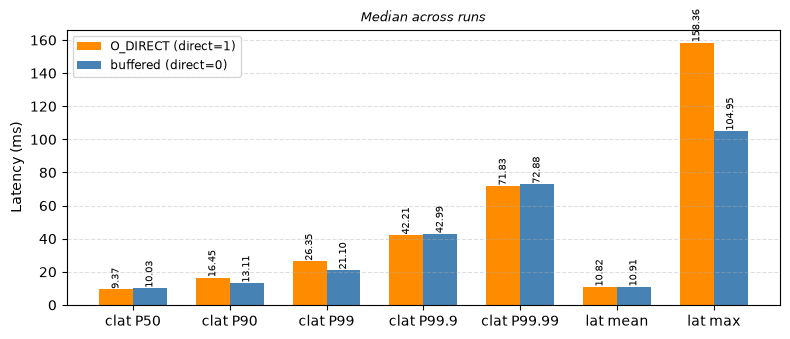

In [6]:
metrics = [
    ("clat_50th_ms",    "clat P50"),
    ("clat_90th_ms",    "clat P90"),
    ("clat_99th_ms",    "clat P99"),
    ("clat_99_9th_ms",  "clat P99.9"),
    ("clat_99_99th_ms", "clat P99.99"),
    ("lat_mean_ms",     "lat mean"),
    ("lat_max_ms",      "lat max"),
]

modes = df["mode"].tolist()
n = len(metrics)
w = 0.35
x = list(range(n))

fig, ax = plt.subplots(figsize=(8, 3.5))
for i, mode in enumerate(modes):
    row = df[df["mode"] == mode].iloc[0]
    vals = [row[col] for col, _ in metrics]
    offset = (i - (len(modes) - 1) / 2) * w
    color = "steelblue" if "buffered" in mode else "darkorange"
    bars = ax.bar([xi + offset for xi in x], vals, w, label=mode, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics])
ax.set_ylabel("Latency (ms)")
ax.set_title("Median across runs", fontsize=9, style="italic")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig("latency_pagecache_vs_direct.pdf", dpi=150)
plt.show()


## CPU Usage (usr / sys)

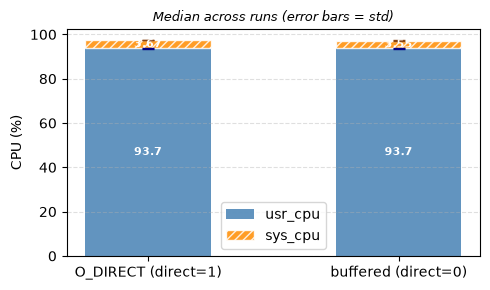

In [7]:
usr_std = df_stats["usr_cpu_std"].values
sys_std = df_stats["sys_cpu_std"].values

x = list(range(len(df)))
w = 0.5
fig, ax = plt.subplots(figsize=(5, 3))

bars_usr = ax.bar(x, df["usr_cpu"], w, label="usr_cpu", color="steelblue", alpha=0.85,
                   yerr=usr_std, capsize=4, error_kw=dict(elinewidth=1, ecolor="navy", capthick=1))
bars_sys = ax.bar(x, df["sys_cpu"], w, bottom=df["usr_cpu"], label="sys_cpu",
                   color="darkorange", alpha=0.85, hatch="////", edgecolor="white",
                   yerr=sys_std, capsize=4, error_kw=dict(elinewidth=1, ecolor="saddlebrown", capthick=1))

for bar_u, uv, sv in zip(bars_usr, df["usr_cpu"], df["sys_cpu"]):
    cx = bar_u.get_x() + bar_u.get_width() / 2
    ax.text(cx, uv / 2, f"{uv:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.text(cx, uv + sv / 2, f"{sv:.2f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df["mode"])
ax.set_ylabel("CPU (%)")
ax.set_title("Median across runs (error bars = std)", fontsize=9, style="italic")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("cpu_usage_pagecache_vs_direct.pdf", dpi=150)
plt.show()


## Claude Key Findings

**Workload:** `rand_write`, bs=1M, numjobs=16, iodepth=16 — the only difference between the
two result sets is `direct=0/--buffered=1` (page cache, 10 runs) vs `direct=1/--buffered=0`
(O_DIRECT, 11 runs, from the 256io sweep).

### 1. Bandwidth and IOPS are essentially unchanged
Median bandwidth is 22.91 GiB/s (buffered) vs 22.93 GiB/s (O_DIRECT) — a **-0.1%** difference,
well within run-to-run noise. IOPS shows the same ~-0.1% gap.

### 2. This suggests the DFS ioengine largely bypasses the kernel page cache either way
For a normal POSIX filesystem, `direct=0` vs `direct=1` usually produces a large bandwidth gap
(buffered writes absorb into page cache, O_DIRECT bypasses it). Here they're identical, which is
consistent with the DFS ioengine talking to DAOS through `libdfs` calls rather than through the
kernel VFS/page cache — so the `direct`/`buffered` fio flags may not materially change the actual
I/O path for this engine. Worth confirming against DAOS/DFS documentation before treating `direct=0`
results as a genuine "buffered" benchmark.

### 3. Median completion latency is slightly higher, but tail latency is lower, under buffered mode
- clat P50: **+7.0%** (buffered slightly higher)
- clat P90 / P99: **-20.3% / -19.9%** (buffered notably lower)
- lat max: **-33.7%** (buffered substantially lower)

The bandwidth/IOPS parity combined with a tail-latency improvement is the main asymmetry worth
digging into further — it may reflect differences in how completion is timestamped/acknowledged
between the two paths rather than a true throughput effect, given sample sizes are only 10 vs 11 runs.

### 4. CPU usage is nearly identical
usr_cpu and sys_cpu differ by ≤3% between modes — no evidence of extra CPU overhead from either path.

**Recommendation:** Because bandwidth/IOPS don't move between `direct=0` and `direct=1` for the DFS
engine, don't rely on this sweep alone to claim a "page cache benefit" for DAOS DFS. If the goal is to
demonstrate real page-cache absorption, a test that goes through `dfuse` (kernel VFS) rather than the
native `dfs` ioengine would be a more faithful comparison.
